In [1]:
# [코드 11-1] 데이터프레임 생성 (딕셔너리 방식)
import pandas as pd

data = {
    'name': ['김철수', '이영희', '박민수', '최지원'],
    'test':    [85, 92, 78, 88],
    'assign1': [90, 85, 80, 95],
    'assign2': [88, 90, 75, 92]
}
df = pd.DataFrame(data)
display(df)  # 또는 print(df)

,name,test,assign1,assign2
0,김철수,85,90,88
1,이영희,92,85,90
2,박민수,78,80,75
3,최지원,88,95,92


In [2]:
df

,name,test,assign1,assign2
0,김철수,85,90,88
1,이영희,92,85,90
2,박민수,78,80,75
3,최지원,88,95,92


In [7]:
# [코드 11-6, 11-7] 열 추출
df['name']                # 한 개 열 → Series 반환
df[['name', 'test']]      # 두 개 이상 열 → DataFrame 반환

# [코드 11-9] 행 순회
for idx, row in df.iterrows():
    print(idx, row['name'], row['test'])

# [코드 11-10] 열 간 연산
df['sum'] = df['test'] + df['assign1'] + df['assign2']

# [코드 11-11] 조건에 맞는 행 추출
df[df['sum'] >= 80]

0 김철수 85
1 이영희 92
2 박민수 78
3 최지원 88


,name,test,assign1,assign2,sum
0,김철수,85,90,88,263
1,이영희,92,85,90,267
2,박민수,78,80,75,233
3,최지원,88,95,92,275


In [8]:
df["name"]

,name
0,김철수
1,이영희
2,박민수
3,최지원


In [9]:
df.loc[df['sum'] >= 270, 'name']

,name
3,최지원


In [13]:
df.loc[df['sum'] >= 270, 'name'].tolist()

['최지원']

In [14]:
# [코드 11-13] 열 이름 변경
df = df.rename(columns={'test': 'exam'})

In [15]:
df

,name,exam,assign1,assign2,sum
0,김철수,85,90,88,263
1,이영희,92,85,90,267
2,박민수,78,80,75,233
3,최지원,88,95,92,275


In [17]:
sort_df = df.sort_values(by='sum')

In [18]:
sort_df

,name,exam,assign1,assign2,sum
2,박민수,78,80,75,233
0,김철수,85,90,88,263
1,이영희,92,85,90,267
3,최지원,88,95,92,275


In [26]:
import numpy as np
df['grade'] = np.where(df['sum'] >= 270, 'A',
              np.where(df['sum'] >= 260, 'B', 'C'))

In [27]:
df

,name,exam,assign1,assign2,sum,grade
0,김철수,85,90,88,263,B
1,이영희,92,85,90,267,B
2,박민수,78,80,75,233,C
3,최지원,88,95,92,275,A


In [28]:
df['result'] = np.where(df['sum'] >= 260, 'pass', 'fail')

In [29]:
df

,name,exam,assign1,assign2,sum,grade,result
0,김철수,85,90,88,263,B,pass
1,이영희,92,85,90,267,B,pass
2,박민수,78,80,75,233,C,fail
3,최지원,88,95,92,275,A,pass


In [31]:
df.to_csv('exam_out.csv')

In [49]:
# [코드 11-22] 누락이 포함된 데이터프레임 생성
import pandas as pd
import numpy as np

data = {
    'name':   ['김철수', '이영희', np.nan, '최지원', '정민호'],
    'gender': ['M', 'F', 'F', np.nan, 'M'],
    'score':  [85, np.nan, 78, 92, np.nan]
}
df1 = pd.DataFrame(data)
display(df1)

,name,gender,score
0,김철수,M,85.0
1,이영희,F,NaN
2,NaN,F,78.0
3,최지원,NaN,92.0
4,정민호,M,NaN


In [36]:
df1.isna().sum()

,0
name,1
gender,1
score,2


In [37]:
df2 = df1.dropna()

In [38]:
df2

,name,gender,score
0,김철수,M,85.0


In [39]:
df2 = df1.dropna(subset=['name', 'score'])

In [40]:
df2

,name,gender,score
0,김철수,M,85.0
3,최지원,NaN,92.0


In [42]:
df1.dropna(inplace=True)

In [43]:
df1

,name,gender,score
0,김철수,M,85.0


In [45]:
df2 = df1.fillna(0)

In [46]:
df2

,name,gender,score
0,김철수,M,85.0
1,이영희,F,0.0
2,0,F,78.0
3,최지원,0,92.0
4,정민호,M,0.0


In [47]:
# [코드 11-29] 열마다 다른 값으로 대체 (딕셔너리)
df2 = df1.fillna({
    'gender': 'etc',   # 범주형 → 'etc'
    'score':  0        # 수치형 → 0
})

In [48]:
df2

,name,gender,score
0,김철수,M,85.0
1,이영희,F,0.0
2,NaN,F,78.0
3,최지원,etc,92.0
4,정민호,M,0.0


In [50]:
df2= df1.fillna({'score': df1['score'].mean()})

In [51]:
df2

,name,gender,score
0,김철수,M,85.0
1,이영희,F,85.0
2,NaN,F,78.0
3,최지원,NaN,92.0
4,정민호,M,85.0


In [55]:
df1 = pd.DataFrame({
    'name':   ['김철수', '이영희', '박민수'],
    'gender': ['M', 'F', 'M'],
    'age':    [21, 22, 20]
})
df2 = pd.DataFrame({
    'name':       ['김철수', '이영희', '박민수'],
    'department': ['컴퓨터공학', '경영학', '토목공학']
})

In [57]:
df1

,name,gender,age
0,김철수,M,21
1,이영희,F,22
2,박민수,M,20


In [58]:
df2

,name,department
0,김철수,컴퓨터공학
1,이영희,경영학
2,박민수,토목공학


In [59]:
df3 = pd.merge(df1, df2, on='name')
display(df3)

,name,gender,age,department
0,김철수,M,21,컴퓨터공학
1,이영희,F,22,경영학
2,박민수,M,20,토목공학


In [61]:
df4 = pd.DataFrame({
    'department':       ['컴퓨터공학', '경영학', '토목공학'],
    'head of department': ['이정수', '김영규', '최희재']
})

In [62]:
df4

,department,head of department
0,컴퓨터공학,이정수
1,경영학,김영규
2,토목공학,최희재


In [63]:
df5 = pd.merge(df3, df4, on='department')

In [64]:
df5

,name,gender,age,department,head of department
0,김철수,M,21,컴퓨터공학,이정수
1,이영희,F,22,경영학,김영규
2,박민수,M,20,토목공학,최희재


In [65]:
df = pd.read_csv('precipitation.csv')

In [66]:
df

,year,spring,summer,autumn,winter
0,2017,124.9,612.7,177.9,75.2
1,2018,383.5,620.6,351.3,68.7
2,2019,175.0,508.2,440.8,168.8
3,2020,173.7,1037.6,270.4,47.8
4,2021,330.5,612.8,256.4,13.3


In [69]:
df = pd.read_csv('학급당학생수.csv', encoding='euc-kr')

In [70]:
df

,항목,시점,서울특별시,제주특별자치도
0,전체,2011,29.36,28.88
1,전체,2012,28.63,28.09
2,전체,2013,27.81,27.26
3,전체,2014,26.96,26.46
4,전체,2015,26.19,25.97
5,전체,2016,25.36,25.53
6,전체,2017,24.60,25.25
7,전체,2018,23.76,24.97
8,전체,2019,22.96,24.47
9,전체,2020,22.45,24.15


In [71]:
!apt-get update -qq
!apt-get install fonts-nanum -qq
!fc-cache -fv

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118212 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no

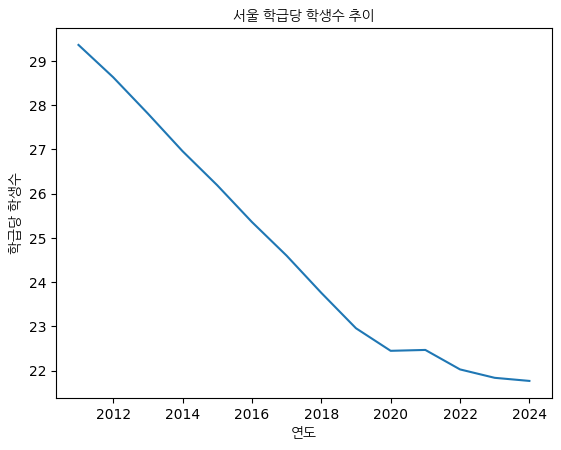

In [77]:
import matplotlib.font_manager as fm
font10 = fm.FontProperties(
    fname='/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
    size=10
)

# [코드 11-51] 사용 예시
import matplotlib.pyplot as plt

plt.plot(df['시점'], df['서울특별시'])
plt.xlabel('연도', fontproperties=font10)
plt.ylabel('학급당 학생수', fontproperties=font10)
plt.title('서울 학급당 학생수 추이', fontproperties=font10)
plt.show()

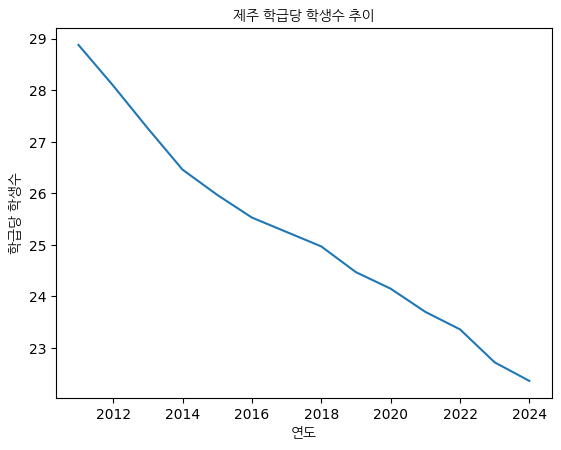

In [81]:
import matplotlib.pyplot as plt

plt.plot(df['시점'], df['제주특별자치도'])
plt.xlabel('연도', fontproperties=font10)
plt.ylabel('학급당 학생수', fontproperties=font10)
plt.title('제주 학급당 학생수 추이', fontproperties=font10)
plt.show()

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [89]:
df = pd.read_csv('car20240731.csv')
print(df.shape)
df.head()

(3498, 13)


,업체명,모델명,연료,변속형식,차량형식,자동차 종류,도심주행연비,고속도로연비,CO2배출량(g_km),1회충전주행거리(km),배기량,등급,출시연도
0,볼보,볼보 V60CCB5 AWD,휘발유,자동,하이브리드,승용차,8.7,11.9,175.0,NaN,1969.0,4등급,2024
1,볼보,볼보 XC60T8 AWD,전기+휘발유,자동,PHEV,승용차,16.6,17.1,33.0,61.0,1969.0,PHEV,2024
2,벤츠,Mercedes-Benz GLC 220 d 4MATIC,경유,자동,하이브리드,승용차,13.8,15.5,130.0,NaN,1993.0,2등급,2024
3,벤츠,Mercedes-Benz E 450 4MATIC,휘발유,자동,하이브리드,승용차,9.0,13.1,162.0,NaN,2998.0,4등급,2024
4,랜드로버,더 뉴 레인지로버 P550e SWB,전기+휘발유,자동,PHEV,승용차,11.5,13.1,35.0,80.0,2996.0,PHEV,2024


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3498 entries, 0 to 3497
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   업체명           3498 non-null   object 
 1   모델명           3498 non-null   object 
 2   연료            3498 non-null   object 
 3   변속형식          3498 non-null   object 
 4   차량형식          3498 non-null   object 
 5   자동차 종류        3498 non-null   object 
 6   도심주행연비        3497 non-null   float64
 7   고속도로연비        3497 non-null   float64
 8   CO2배출량(g_km)  3186 non-null   float64
 9   1회충전주행거리(km)  403 non-null    float64
 10  배기량           3187 non-null   float64
 11  등급            3498 non-null   object 
 12  출시연도          3498 non-null   int64  
dtypes: float64(5), int64(1), object(7)
memory usage: 355.4+ KB


In [92]:
df[['배기량', '고속도로연비', 'CO2배출량(g_km)']].describe()

,배기량,고속도로연비,CO2배출량(g_km)
count,3187.000000,3497.000000,3186.000000
mean,2557.875118,11.752617,168.908035
std,965.196309,4.508477,48.694492
min,0.000000,0.000000,14.000000
25%,1995.000000,9.800000,137.000000
50%,2199.000000,11.800000,167.000000
75%,2997.000000,14.100000,199.000000
max,6749.000000,92.600000,354.000000


In [96]:
df1 = df[df['연료'] == '휘발유']
df2 = df[df['연료'] == '경유']

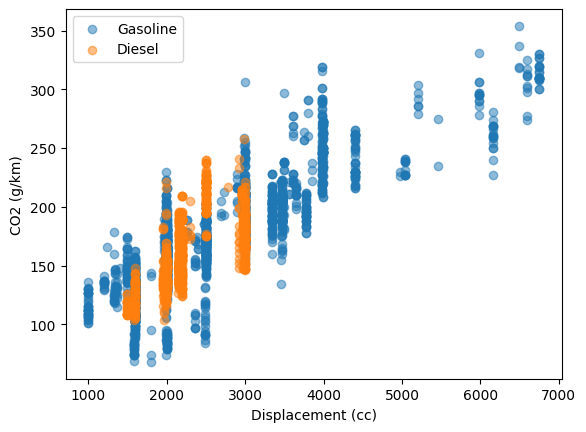

In [98]:
plt.scatter(df1['배기량'], df1['CO2배출량(g_km)'], alpha=0.5, label='Gasoline')
plt.scatter(df2['배기량'], df2['CO2배출량(g_km)'], alpha=0.5, label='Diesel')
plt.xlabel('Displacement (cc)')
plt.ylabel('CO2 (g/km)')
plt.legend()
plt.show()

In [100]:
r1 = df1['배기량'].corr(df1['CO2배출량(g_km)'])
r2 = df2['배기량'].corr(df2['CO2배출량(g_km)'])

print(f'휘발유 차량 상관계수: {r1:.3f}')
print(f'경유  차량 상관계수: {r2:.3f}')

휘발유 차량 상관계수: 0.856
경유  차량 상관계수: 0.656
